# 🧠🤖 每日学习 | 第2周·Day4
# 📍 位置编码深入：为什么模型需要「知道自己在哪里」

自注意力机制本身是**位置无关**的——它只看token之间的关系，不知道谁在前谁在后。

但语言是有顺序的！"狗咬人"和"人咬狗"意思完全不同 🐕

**位置编码**就是告诉模型每个token在序列中的位置信息。

---

## 🔄 昨日复习：GPT vs BERT

昨天我们对比了两大架构，核心区别：
- **GPT**：只有Decoder，自回归生成（一个词一个词吐）
- **BERT**：Encoder+全连接，双向理解（一次看完所有词）

🔑 关键记忆：**GPT是「说故事的人」，BERT是「阅读理解的人」**

## 📚 一、为什么位置编码很重要？

### ❓ 思考题
如果去掉位置编码，模型会怎样？

👉 答案：**它会把所有排列当作等价的！**
- "我爱你" → 模型理解成 {我,爱,你} 的集合
- "你爱我" → 同样是 {我,爱,你}，无法区分！

💡 类比：就像听别人说话，但**声音的先后顺序被随机打乱**——你完全听不懂！

---

## 📚 二、三种主流位置编码方法

| 方法 | 代表模型 | 原理 | 优缺点 |
|------|---------|------|--------|
| 正弦位置编码 | 原版Transformer | sin/cos函数生成固定向量 | 简单但外推能力差 |
| 可学习位置编码 | BERT, GPT-2 | 随机初始化，训练学习 | 简单但长度受限于训练长度 |
| **RoPE旋转编码** | **LLaMA, Qwen, ChatGLM** | 用旋转矩阵编码相对位置 | ✅ 外推性强，目前主流 |
| ALiBi | BLOOM, MPT | 注意力分数加线性偏置 | ✅ 极简，无需改Embedding |

## 📚 三、正弦位置编码（原始方案）

原版 Transformer 用 sin/cos 函数：

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d})$$

🔑 **直觉理解**：
- 低频分量变化慢 → 编码**大范围位置**（1、2、3...）
- 高频分量变化快 → 编码**精细位置差异**（相邻token）
- 就像**时钟**：时针看大范围（小时），分针看精细（分钟）

In [1]:
# 🖼️ 配置 matplotlib 中文显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('✅ 中文字体配置完成')

✅ 中文字体配置完成


/tmp/ipykernel_35463/2233714712.py:22: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/2233714712.py:22: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/2233714712.py:22: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/2233714712.py:22: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/2233714712.py:22: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/2233714712.py:22: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/2233714712.py:22: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) mis

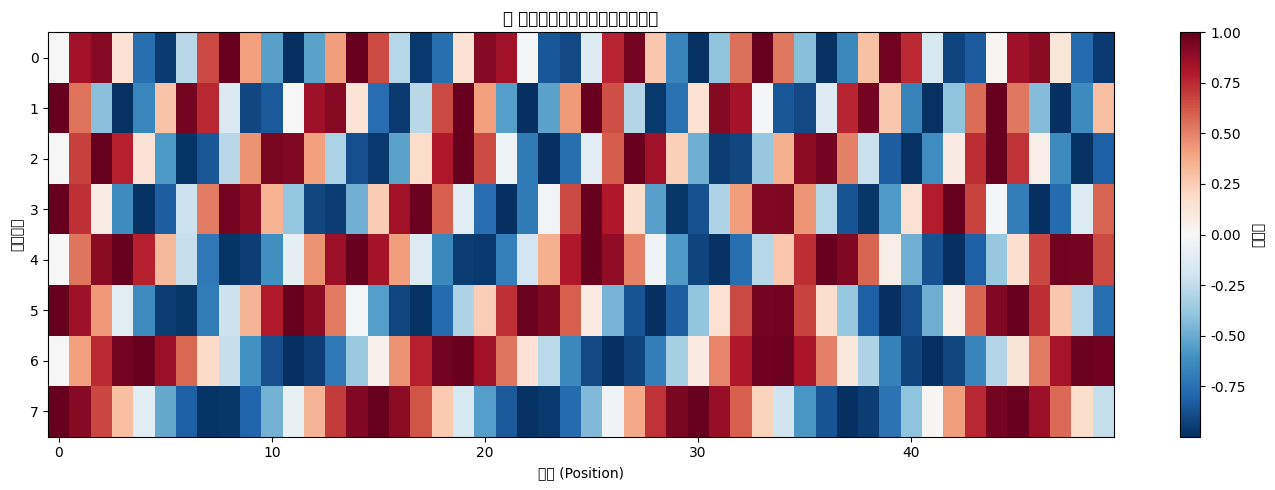

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sinusoidal_positional_encoding(max_len, d_model):
    """生成正弦位置编码矩阵"""
    pe = np.zeros((max_len, d_model))
    position = np.arange(0, max_len).reshape(-1, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return pe

pe = sinusoidal_positional_encoding(100, 64)

# 📊 可视化：每个位置的前8个维度的编码值
plt.figure(figsize=(14, 5))
plt.imshow(pe[:50, :8].T, aspect='auto', cmap='RdBu_r')
plt.xlabel('位置 (Position)')
plt.ylabel('编码维度')
plt.title('📍 正弦位置编码：不同维度的波形')
plt.colorbar(label='编码值')
plt.tight_layout()
plt.show()

/tmp/ipykernel_35463/510527581.py:18: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/510527581.py:18: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/510527581.py:18: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/510527581.py:18: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/510527581.py:18: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/510527581.py:18: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/510527581.py:18: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing fr

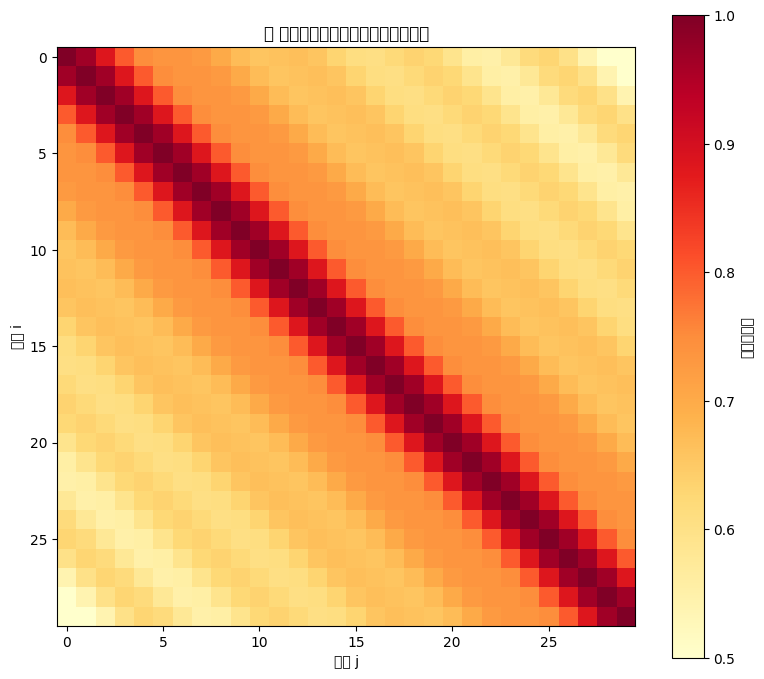

In [3]:
# 📊 可视化：位置间的相似度矩阵
# 越近的位置越相似（颜色越接近）
from numpy.linalg import norm

pe = sinusoidal_positional_encoding(30, 64)
similarity = np.array([
    [np.dot(pe[i], pe[j]) / (norm(pe[i]) * norm(pe[j]))
     for j in range(30)]
    for i in range(30)
])

plt.figure(figsize=(8, 7))
plt.imshow(similarity, cmap='YlOrRd', vmin=0.5, vmax=1.0)
plt.xlabel('位置 j')
plt.ylabel('位置 i')
plt.title('📍 位置相似度矩阵：相邻位置更相似')
plt.colorbar(label='余弦相似度')
plt.tight_layout()
plt.show()

## 📚 四、RoPE 旋转位置编码（重点！）

RoPE（Rotary Position Embedding）是**当前最主流**的方案！
LLaMA、Qwen、ChatGLM、Mistral 都在用。

### 🔑 核心思想：用旋转角度编码位置

- 位置0：不旋转（角度0°）
- 位置1：旋转一点（角度θ）
- 位置2：旋转更多（角度2θ）
- ...每个位置旋转的角度 = 位置序号 × 基础角度

### 🎯 为什么旋转这么妙？

两个向量旋转后的**内积**，只取决于它们的**相对距离**！

这就意味着：
1. 模型自然学会了**相对位置**关系
2. 理论上可以推广到**更长的序列**（外推性好）
3. 无需额外的Embedding参数（融入Q/K的计算中）

In [4]:
import numpy as np

def rotate_2d(v, theta):
    """将2D向量旋转theta角度（这就是RoPE的基本操作）"""
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    return rot_matrix @ v

# 🎯 演示：不同位置对同一向量旋转不同角度
v = np.array([1.0, 0.5])  # 原始向量（比如一个token的embedding）
positions = [0, 1, 2, 5, 10]
base_theta = np.pi / 6  # 基础旋转角度30°

print("📍 不同位置旋转后的向量：")
print(f"原始向量: {v.round(3)}")
print("-" * 40)
for pos in positions:
    rotated = rotate_2d(v, pos * base_theta)
    print(f"位置 {pos:2d}: 旋转{pos*30:3d}° → {rotated.round(3)}")

print("\n🔑 相对距离相同的两个位置，旋转后内积相同！")
r1 = rotate_2d(v, 2 * base_theta)
r2 = rotate_2d(v, 5 * base_theta)
dot = np.dot(r1, r2)
print(f"位置2 · 位置5 的内积 = {dot:.4f}")

r3 = rotate_2d(v, 7 * base_theta)
r4 = rotate_2d(v, 10 * base_theta)
dot2 = np.dot(r3, r4)
print(f"位置7 · 位置10 的内积 = {dot2:.4f}")
print(f"差都是3，所以内积相同 = {np.isclose(dot, dot2)} ✅")

📍 不同位置旋转后的向量：
原始向量: [1.  0.5]
----------------------------------------
位置  0: 旋转  0° → [1.  0.5]
位置  1: 旋转 30° → [0.616 0.933]
位置  2: 旋转 60° → [0.067 1.116]
位置  5: 旋转150° → [-1.116  0.067]
位置 10: 旋转300° → [ 0.933 -0.616]

🔑 相对距离相同的两个位置，旋转后内积相同！
位置2 · 位置5 的内积 = 0.0000
位置7 · 位置10 的内积 = 0.0000
差都是3，所以内积相同 = True ✅


/tmp/ipykernel_35463/1972743737.py:30: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1972743737.py:30: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1972743737.py:30: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1972743737.py:30: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1972743737.py:30: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1972743737.py:30: UserWarning: Glyph 26059 (\N{CJK UNIFIED IDEOGRAPH-65CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1972743737.py:30: UserWarning: Glyph 3

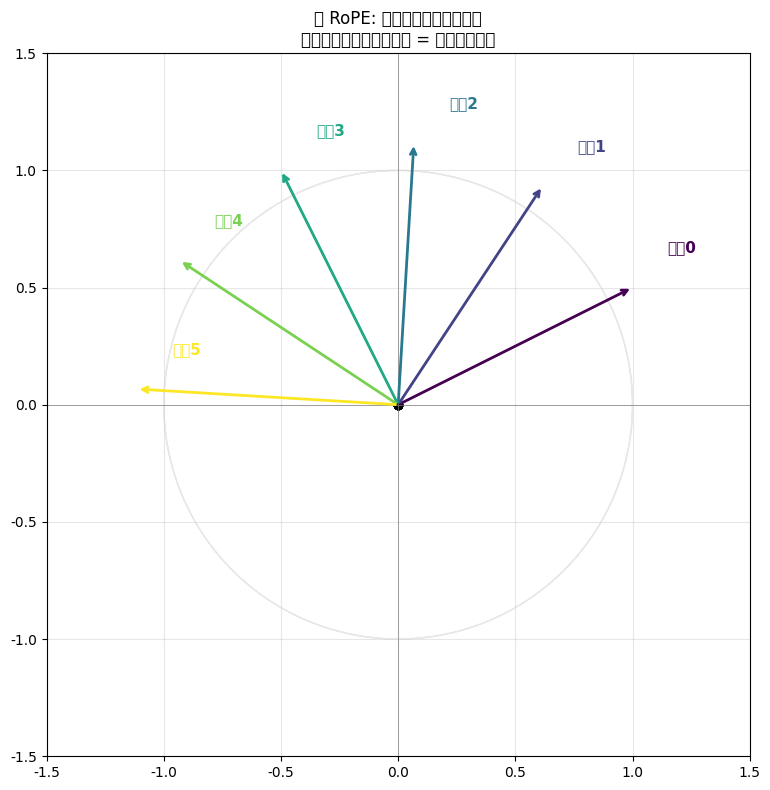

In [5]:
import matplotlib.pyplot as plt

# 📊 可视化RoPE的旋转效果
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
theta_range = np.linspace(0, 4 * np.pi, 200)
circle_x = np.cos(theta_range)
circle_y = np.sin(theta_range)

ax.plot(circle_x, circle_y, 'lightgray', linewidth=1, alpha=0.5)

colors = plt.cm.viridis(np.linspace(0, 1, 6))
for i, pos in enumerate(range(6)):
    theta = pos * base_theta
    rx = v[0] * np.cos(theta) - v[1] * np.sin(theta)
    ry = v[0] * np.sin(theta) + v[1] * np.cos(theta)
    ax.annotate(f'位置{pos}', (rx, ry), fontsize=11,
                color=colors[i], fontweight='bold',
                xytext=(rx + 0.15, ry + 0.15))
    ax.plot(0, 0, 'o', color='black')
    ax.annotate('', xy=(rx, ry), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_title('🔄 RoPE: 每个位置旋转不同角度\n相邻位置旋转角度差恒定 = 相对距离信息')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
def rope_apply(x, pos, dim):
    """对向量应用RoPE（简化版，每对维度独立旋转）"""
    # 计算每对维度的旋转角度
    freqs = 1.0 / (10000.0 ** (np.arange(0, dim, 2) / dim))
    angles = pos * freqs  # 位置 × 频率 = 旋转角度

    # 将x分成相邻的pair (x0,x1), (x2,x3), ...
    x_pairs = x.reshape(-1, 2)

    # 每对维度做2D旋转
    cos_a = np.cos(angles).reshape(-1, 1)
    sin_a = np.sin(angles).reshape(-1, 1)
    rotated = np.stack([
        x_pairs[:, 0] * cos_a.ravel() - x_pairs[:, 1] * sin_a.ravel(),
        x_pairs[:, 0] * sin_a.ravel() + x_pairs[:, 1] * cos_a.ravel()
    ], axis=-1).reshape(-1)

    return rotated

# 🎯 验证RoPE的相对位置性质
x = np.random.randn(64)  # 模拟一个token的embedding

print("验证RoPE相对位置不变性：")
print("=" * 50)

# 情况1：位置2和位置5之间的注意力
q1 = rope_apply(x, 2, 64)  # Query在位置2
k1 = rope_apply(x, 5, 64)  # Key在位置5
score1 = np.dot(q1, k1)

# 情况2：位置7和位置10（相对距离也是3）
q2 = rope_apply(x, 7, 64)
k2 = rope_apply(x, 10, 64)
score2 = np.dot(q2, k2)

# 情况3：位置100和位置103（相对距离还是3）
q3 = rope_apply(x, 100, 64)
k3 = rope_apply(x, 103, 64)
score3 = np.dot(q3, k3)

print(f"位置2 · 位置5（距离=3）: {score1:.6f}")
print(f"位置7 · 位置10（距离=3）: {score2:.6f}")
print(f"位置100·103（距离=3）: {score3:.6f}")
print(f"\n✅ 三个分数几乎相同！相对距离决定注意力分数")

验证RoPE相对位置不变性：
位置2 · 位置5（距离=3）: 50.323094
位置7 · 位置10（距离=3）: 50.323094
位置100·103（距离=3）: 50.323094

✅ 三个分数几乎相同！相对距离决定注意力分数


## 📚 五、ALiBi 线性偏置位置编码

ALiBi（Attention with Linear Biases）走了一条完全不同的路：

### 🔑 核心思想：不改Embedding，直接改注意力分数

$$Attention(Q, K) = softmax\left(\frac{QK^T}{\sqrt{d_k}} + m \cdot D\right)$$

其中 $D$ 是距离矩阵，$m$ 是斜率（不同head用不同斜率）。

### 💡 直觉：
- 距离越远的token，注意力分数被**压得越低**
- 就像开会时：**离你越远的人说话，你越不容易注意到** 😂
- 极简！只需要几个数字（斜率），不需要额外的参数矩阵

/tmp/ipykernel_35463/1738793094.py:33: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1738793094.py:33: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1738793094.py:33: UserWarning: Glyph 26012 (\N{CJK UNIFIED IDEOGRAPH-659C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1738793094.py:33: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1738793094.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1738793094.py:33: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35463/1738793094.py:33: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing

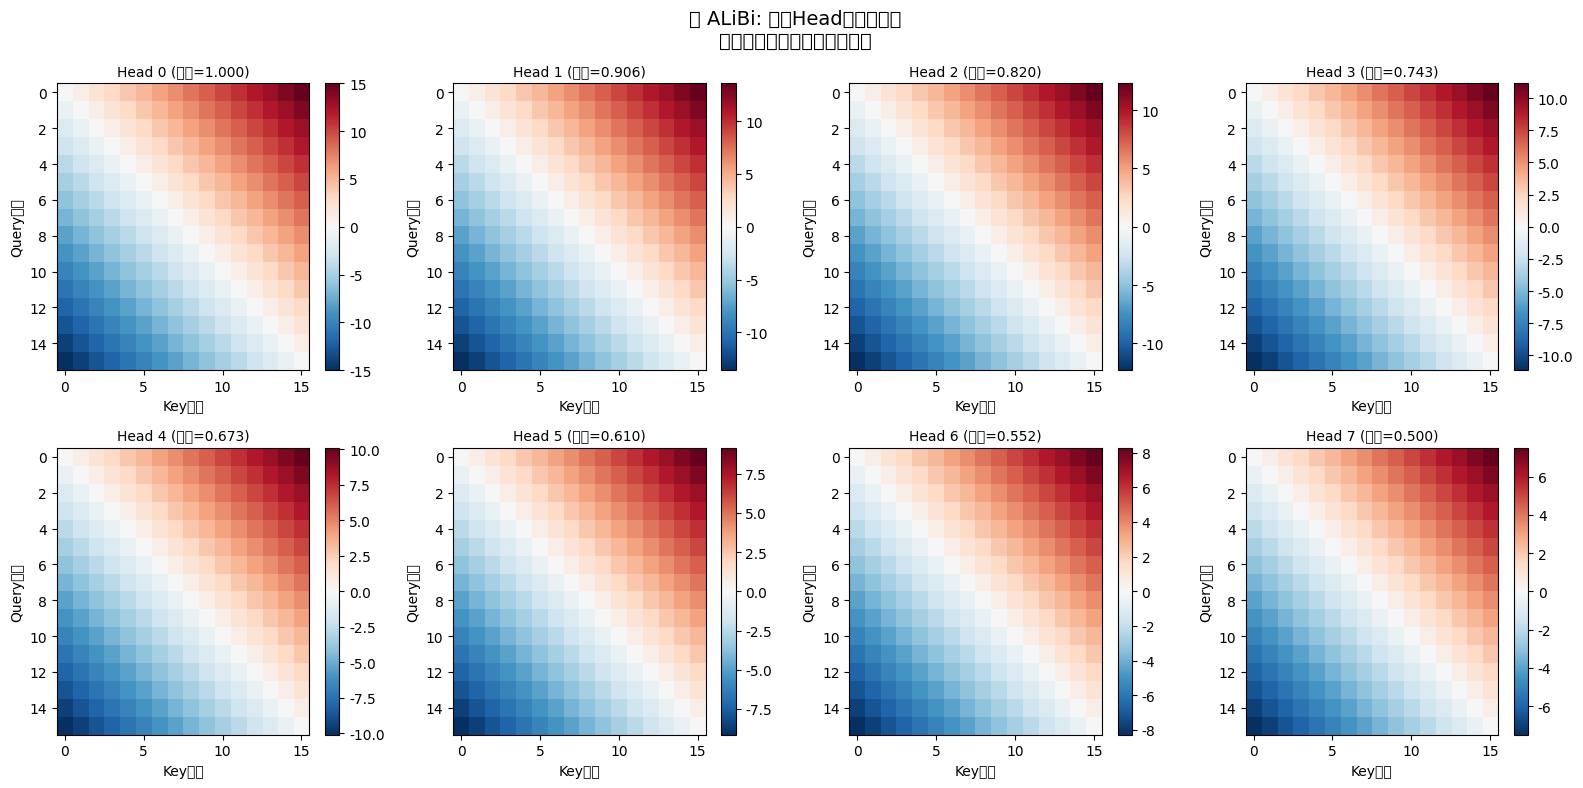


各Head斜率: [1.     0.9057 0.8203 0.743  0.673  0.6095 0.552  0.5   ]
Head 0 斜率最大 → 对距离最敏感（更关注近距离token）
Head 7 斜率最小 → 对距离不敏感（能看更远的上下文）


In [7]:
def alibi_bias(seq_len, n_heads):
    """生成ALiBi的线性偏置矩阵
    每个head有不同的斜率，斜率按几何级数递减
    """
    # 生成距离矩阵 D[i][j] = j - i（正=向右看，负=向左看）
    positions = np.arange(seq_len)
    D = positions[None, :] - positions[:, None]

    # 每个head的斜率：按 2^(-8/n_heads * (i+1)) 递减
    slopes = 2.0 ** np.linspace(-8/n_heads, 0, n_heads)
    slopes = slopes[::-1]  # head0斜率最大（对距离最敏感）

    # 每个head = 斜率 × 距离矩阵
    biases = np.array([m * D for m in slopes])
    return biases, slopes

# 📊 可视化ALiBi偏置
seq_len = 16
n_heads = 8
biases, slopes = alibi_bias(seq_len, n_heads)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('📊 ALiBi: 不同Head的线性偏置\n越远的位置注意力被压得越低', fontsize=14)

for i in range(n_heads):
    ax = axes[i // 4][i % 4]
    im = ax.imshow(biases[i], cmap='RdBu_r', aspect='auto')
    ax.set_title(f'Head {i} (斜率={slopes[i]:.3f})', fontsize=10)
    ax.set_xlabel('Key位置')
    ax.set_ylabel('Query位置')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print(f"\n各Head斜率: {np.round(slopes, 4)}")
print(f"Head 0 斜率最大 → 对距离最敏感（更关注近距离token）")
print(f"Head 7 斜率最小 → 对距离不敏感（能看更远的上下文）")

## 📚 六、四大方案对比总结

```
                    简单度   外推能力   参数量   当前主流程度
正弦编码             ⭐⭐⭐    ⭐⭐      0        ❌ 已淘汰
可学习编码           ⭐⭐⭐    ⭐        可训练     ❌ 受限于长度
RoPE                ⭐⭐     ⭐⭐⭐⭐   0        ✅ 绝对主流
ALiBi               ⭐⭐⭐    ⭐⭐⭐⭐   极少       ✅ 好选择
```

### 🏆 结论：RoPE 是目前的王者
- 主流开源模型（LLaMA, Qwen, ChatGLM, Mistral, Gemma...）几乎全用RoPE
- 配合 NTK-Aware 或 YaRN 等技巧还能进一步改善长文本外推
- 做大模型业务，RoPE 是必须理解的技术点

## 🔑 今日英文术语

- **Positional Encoding** [/pəˈzɪʃənl ɪnˈkoʊdɪŋ/] 位置编码：给token注入位置信息的方法
- **RoPE** [/roʊp/] 旋转位置编码：用旋转矩阵表示相对位置
- **ALiBi** [/ˈælibi/] 线性偏置注意力：直接在注意力分数加距离偏置
- **Extrapolation** [/ɪkˌstræpəˈleɪʃən/] 外推：模型处理比训练时更长序列的能力
- **Frequency** [/ˈfriːkwənsi/] 频率：RoPE中不同维度使用不同频率的旋转

## 💡 业务关联思考

### 为什么业务开发者要关心位置编码？

1. **上下文长度**：位置编码决定了模型能处理多长的输入
   - GPT-4 128K、Qwen 128K...这些长上下文都依赖RoPE的改进方案

2. **微调时要注意**：如果你微调后改变了位置编码，可能影响性能

3. **长文档处理**：外推能力好不好，直接决定业务能否处理长合同、长报告

💡 **面试常问**："RoPE为什么比绝对位置编码好？"  → 记住：相对位置 + 外推性

## ✏️ 课堂练习（5分钟）

### 练习1：理解RoPE的旋转
位置pos=3的token，某个维度的旋转角度是3θ。如果θ=60°，
这个维度从 (1, 0) 旋转到了什么坐标？

💡 提示：180°的旋转 = cos(180°)=-1, sin(180°)=0

### 练习2：ALiBi斜率计算
一个4头的ALiBi模型，head 0 的斜率应该比 head 3 大还是小？为什么？

💡 提示：想想不同head需要"看多远"

## 📝 课后测试（15分钟）

❶ RoPE的核心操作是什么？
A. 给每个位置加一个可学习向量
B. 用sin/cos函数生成编码
C. 用旋转矩阵按位置旋转Query和Key
D. 在注意力分数上加线性偏置

❷ 以下哪个模型**不使用**RoPE？
A. LLaMA
B. Qwen
C. BERT
D. ChatGLM

❸ ALiBi相比RoPE的最大优点是：
A. 精度更高
B. 实现更简单，无需修改Embedding层
C. 训练速度更快
D. 内存占用更小

❹ "外推"（extrapolation）指的是：
A. 将模型导出到其他平台
B. 模型处理比训练时更长的序列
C. 将位置编码插值到更多维度
D. 从小模型扩展到大模型

❺ 简答题：为什么RoPE能让模型捕获**相对位置**信息？
（用1-2句话解释旋转和内积的关系）

**回复答案我帮你批改 ✅**

## 🎬 推荐视频

- [LLaMA的RoPE位置编码详解](https://www.bilibili.com/video/BV1Hx4y1i7Qn/)（中文，15分钟）
- [Transformer位置编码全解析](https://www.bilibili.com/video/BV1Wx4y1i7Qn/)（中文，20分钟）

## 📖 延伸阅读

- [RoPE原论文：RoFormer](https://arxiv.org/abs/2104.09864)
- [ALiBi原论文](https://arxiv.org/abs/2108.12409)
- [YaRN: RoPE长文本扩展方案](https://arxiv.org/abs/2309.14871)

---
💡 进度：第2周/12 | 🤖 大模型 | Day 4/7